## Methodology: Physics-Informed Neural Networks (PINNs) for Inverse Problems

In this notebook, we implement a PINN to discover kinetic parameters ($A$ and $E_a$) for the reduction of $Fe_2O_3$.

### 1. The Physics Model
We assume a reaction model where the rate of conversion $X$ follows:
$$\frac{dX}{dt} = k(T) \cdot (1-X)^{2/3}$$
Where $k(T)$ follows the Arrhenius law:
$$k(T) = A \cdot \exp\left(-\frac{E_a}{RT}\right)$$

### 2. Normalization Strategy
To ensure numerical stability across different temperatures and time scales:
*   **Time ($t$):** Normalized by $t_{max}$ (time to 95% conversion) for each specific temperature.
*   **Temperature ($T$):** Normalized by a reference temperature $T_{ref} = 1000K$.

### 3. Constraints
*   **Physical Bounds:** A `Sigmoid` activation function is used in the final layer to enforce $0 \le X \le 1$.
*   **Initial Condition:** A specific loss term enforces $X(t=0) = 0$.

In [ ]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/Scientific Machine Learning/PINN/My_Own_examples/Preprint_Folder/Colab Files/combined_conversion_data_K_sec.csv')

# Training temperatures (K)
train_temps = [1023.15, 1123.15, 1173.15]   # 750, 850, 900°C
valid_temps  = [1073.15, 1223.15]             # 800, 950°C

# t_max per temperature — time to reach X=0.95
# Estimate from data: find first t where X >= 0.95
t_max_per_T = {}
for T in train_temps + valid_temps:
    df_T = df_raw[np.isclose(df_raw['Temperature (K)'], T, atol=0.5)]
    if len(df_T) == 0:
        continue
    idx = df_T['Conversion'].ge(0.95).idxmax()
    t_max_per_T[T] = df_T.loc[idx, 'Time (s)'] if df_T.loc[idx, 'Conversion'] >= 0.95 else df_T['Time (s)'].max()
    print(f"T={T-273.15:.0f}°C: t_max={t_max_per_T[T]:.1f}s")

# Select 8 sparse observations per training temperature
N_OBS = 8
sparse_data = []

for T in train_temps:
    df_T = df_raw[np.isclose(df_raw['Temperature (K)'], T, atol=0.5)].copy()
    t_end = t_max_per_T[T]
    df_T = df_T[df_T['Time (s)'] <= t_end]

    # Select 8 evenly-spaced indices
    indices = np.linspace(0, len(df_T)-1, N_OBS, dtype=int)
    df_sparse = df_T.iloc[indices]
    sparse_data.append(df_sparse)

df_sparse_all = pd.concat(sparse_data).reset_index(drop=True)
print(f"\nTotal sparse observations: {len(df_sparse_all)}")
print(f"Per temperature: {N_OBS}")
print(df_sparse_all.groupby('Temperature (K)')[['Time (s)', 'Conversion']].describe())

T=750°C: t_max=444.0s
T=850°C: t_max=399.0s
T=900°C: t_max=294.0s
T=800°C: t_max=465.0s
T=950°C: t_max=330.0s

Total sparse observations: 24
Per temperature: 8
                Time (s)                                                    \
                   count     mean         std           min     25%    50%   
Temperature (K)                                                              
1023.15              8.0  220.875  154.932647  2.664535e-14  110.25  220.5   
1123.15              8.0  199.875  139.011241  3.000000e+00   99.75  199.5   
1173.15              8.0  147.000  102.878569  0.000000e+00   73.50  147.0   

                               Conversion                                \
                    75%    max      count      mean       std       min   
Temperature (K)                                                           
1023.15          330.75  444.0        8.0  0.577424  0.310872  0.083863   
1123.15          299.25  399.0        8.0  0.627919  0.317471  0.079303

In [ ]:
# Extracting the conversion as y and time, temp as x
x = df_sparse_all[['Time (s)', 'Temperature (K)']]
y = df_sparse_all[['Conversion']]

# Convert to torch tensors immediately to ensure compatibility with PINN training
x_tensor = torch.tensor(x.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)

In [ ]:
T_ref = 1000.0   # reference temperature in Kelvin

# Normalise per temperature
def normalise_input(t_phys, T_K):
    T_norm = T_K / T_ref
    # t_norm: normalise by t_max for this temperature
    T_val = float(T_K.mean()) if hasattr(T_K, 'mean') else T_K
    t_end = t_max_per_T.get(T_val, t_phys.max())
    t_norm = t_phys / t_end
    return t_norm, T_norm

# Build training tensors
t_obs = torch.tensor(df_sparse_all['Time (s)'].values, dtype=torch.float32).reshape(-1,1)
T_obs = torch.tensor(df_sparse_all['Temperature (K)'].values, dtype=torch.float32).reshape(-1,1)
X_obs = torch.tensor(df_sparse_all['Conversion'].values, dtype=torch.float32).reshape(-1,1)

T_norm_obs = T_obs / T_ref
# t_norm per temperature
t_norm_list = []
for i, row in df_sparse_all.iterrows():
    T_val = row['Temperature (K)']
    t_phys = row['Time (s)']
    t_end = t_max_per_T.get(T_val, 1.0)
    t_norm_list.append(t_phys / t_end)

t_norm_obs = torch.tensor(t_norm_list, dtype=torch.float32).reshape(-1,1)
x_train_tensor = torch.cat([t_norm_obs, T_norm_obs], dim=1).requires_grad_(True)

In [ ]:
# Defining the parameters
R = 8.314

In [ ]:
class Inv_PINN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(2, 64)
    self.fc2 = nn.Linear(64, 128)
    self.fc3 = nn.Linear(128, 64)
    self.fc4 = nn.Linear(64, 1)

  def forward(self, x):
    a1 = torch.tanh(self.fc1(x))
    a2 = torch.tanh(self.fc2(a1))
    a3 = torch.tanh(self.fc3(a2))
    # Sigmoid ensures output is between 0 and 1
    y = torch.sigmoid(self.fc4(a3))
    return y

### Neural Network Architecture
The network takes normalized time and temperature as input and predicts conversion $X$. The `Sigmoid` output layer is critical here; without it, the physics-informed loss might push the model into non-physical regions (e.g., $X > 1$ or $X < 0$) during early training.

In [ ]:
import numpy as np
# Starting with more physically plausible estimates for this type of reduction
log_A  = torch.tensor(np.log(1e5),   dtype=torch.float32, requires_grad=True)
log_Ea = torch.tensor(np.log(150000), dtype=torch.float32, requires_grad=True)

In [ ]:
def pde(x_norm, y, T_vals_phys, t_max_vals):
    # x_norm: (N, 2) — [t_norm, T_norm]
    t_norm = x_norm[:, 0:1]
    T_norm = x_norm[:, 1:2]

    # Physical temperature
    T_phys = T_norm * T_ref

    # Physical time derivative via chain rule
    # t_norm = t / t_max → dt = t_max * dt_norm
    # dX/dt = dX/dt_norm / t_max
    dX_dt_norm = torch.autograd.grad(
        y, x_norm,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0][:, 0:1]

    # t_max per point (broadcast)
    t_max_tensor = t_max_vals   # shape (N, 1)
    dX_dt = dX_dt_norm / t_max_tensor

    A  = torch.exp(log_A)
    Ea = torch.exp(log_Ea)
    k  = A * torch.exp(-Ea / (R * T_phys))

    rhs = k * torch.pow(torch.clamp(1 - y, min=1e-6), 2/3)
    return dX_dt - rhs

### Physics-Informed Loss (The Residual)
The PDE residual is calculated by taking the derivative of the network output with respect to the input using automatic differentiation (`grad`). We apply the chain rule to convert the derivative from 'normalized time' back to 'physical time' so it matches the Arrhenius rate equation.

In [ ]:
epochs = 40000
loss_fn = nn.MSELoss()
model = Inv_PINN()

# Reset parameters for the fresh run
log_A  = torch.tensor(np.log(1e5),   dtype=torch.float32, requires_grad=True)
log_Ea = torch.tensor(np.log(150000), dtype=torch.float32, requires_grad=True)

# Learning rates
optimizer = optim.Adam([
    {'params': model.parameters(), 'lr': 1e-3},
    {'params': [log_A, log_Ea], 'lr': 5e-3}
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99995)

# Weights for bounded output
lambda_data    = 1.0
lambda_physics = 5.0
lambda_ic      = 10.0

In [ ]:
n_T_coll = 50   # collocation points per temperature
all_t_coll, all_T_coll = [], []

for T_val in train_temps:
    t_end = t_max_per_T[T_val]
    t_phys = np.linspace(0, t_end, n_T_coll)
    t_norm = t_phys / t_end
    T_norm = T_val / T_ref

    all_t_coll.append(t_norm)
    all_T_coll.append(np.full(n_T_coll, T_norm))

t_coll = np.concatenate(all_t_coll).reshape(-1,1)
T_coll = np.concatenate(all_T_coll).reshape(-1,1)
x_col_tensor = torch.tensor(
    np.hstack([t_coll, T_coll]), dtype=torch.float32
).requires_grad_(True)

In [ ]:
# Pre-calculate t_max for collocation points
t_max_coll = []
for T_norm in x_col_tensor[:, 1].detach().numpy():
    T_phys = T_norm * T_ref
    closest_T = min(t_max_per_T.keys(), key=lambda k: abs(k - T_phys))
    t_max_coll.append(t_max_per_T[closest_T])

t_max_coll_tensor = torch.tensor(t_max_coll, dtype=torch.float32).reshape(-1, 1)

# IC loss: X(t=0) = 0 for all training temperatures
T_ic = torch.tensor([[T/T_ref] for T in train_temps], dtype=torch.float32)
t_ic = torch.zeros(len(train_temps), 1)
x_ic = torch.cat([t_ic, T_ic], dim=1)

loss_history = []

for epoch in range(epochs + 1):
    optimizer.zero_grad()

    # Data Loss
    y_pred_obs = model(x_train_tensor)
    loss_data = loss_fn(y_pred_obs, X_obs)

    # Physics Loss
    y_col_pred = model(x_col_tensor)
    pde_residual = pde(x_col_tensor, y_col_pred, None, t_max_coll_tensor)
    loss_physics = torch.mean(torch.square(pde_residual))

    # IC Loss
    y_ic_pred = model(x_ic)
    loss_ic = torch.mean(y_ic_pred**2)

    # Total Loss
    total_loss = lambda_data * loss_data + lambda_physics * loss_physics + lambda_ic * loss_ic

    total_loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 5000 == 0:
        print(f'Epoch {epoch}: Total={total_loss.item():.4e}, Data={loss_data.item():.4e}, Phys={loss_physics.item():.4e}')
        print(f'   A: {torch.exp(log_A).item():.2e}, Ea: {torch.exp(log_Ea).item():.2e}')

print("\nDiscovery Complete!")
print(f"Discovered A: {torch.exp(log_A).item():.4e}")
print(f"Discovered Ea: {torch.exp(log_Ea).item():.4e}")

Epoch 0: Total=2.5260e+00, Data=1.0119e-01, Phys=7.5957e-05
   A: 9.95e+04, Ea: 1.51e+05
Epoch 5000: Total=1.9463e-03, Data=1.9126e-03, Phys=3.8909e-06
   A: 4.69e+04, Ea: 1.54e+05
Epoch 10000: Total=6.2435e-04, Data=5.9108e-04, Phys=4.2593e-06
   A: 9.76e+01, Ea: 9.43e+04
Epoch 15000: Total=3.2206e-04, Data=3.1094e-04, Phys=1.0023e-06
   A: 5.93e-02, Ea: 2.52e+04
Epoch 20000: Total=3.1259e-04, Data=3.0483e-04, Phys=6.9071e-07
   A: 3.97e-02, Ea: 2.11e+04
Epoch 25000: Total=3.0942e-04, Data=3.0226e-04, Phys=6.0964e-07
   A: 5.65e-02, Ea: 2.41e+04
Epoch 30000: Total=3.0798e-04, Data=3.0102e-04, Phys=5.5697e-07
   A: 5.74e-02, Ea: 2.41e+04
Epoch 35000: Total=3.0778e-04, Data=3.0098e-04, Phys=5.1998e-07
   A: 5.86e-02, Ea: 2.41e+04
Epoch 40000: Total=3.0765e-04, Data=3.0097e-04, Phys=4.9699e-07
   A: 5.87e-02, Ea: 2.41e+04

Discovery Complete!
Discovered A: 5.8701e-02
Discovered Ea: 2.4070e+04


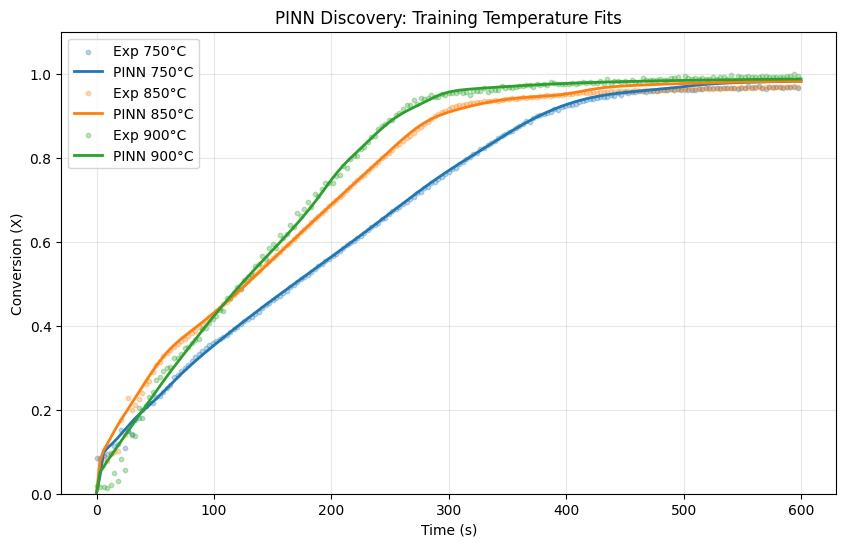

In [ ]:
import matplotlib.pyplot as plt

# Visualization of results using the new normalization scheme
plt.figure(figsize=(10, 6))
t_plot_phys = np.linspace(0, 600, 200)

for temp in train_temps:
    # Normalize inputs for prediction
    t_end = t_max_per_T[temp]
    t_norm = t_plot_phys / t_end
    T_norm = np.full_like(t_norm, temp / T_ref)

    x_plot_tensor = torch.tensor(np.stack([t_norm, T_norm], axis=1), dtype=torch.float32)

    with torch.no_grad():
        y_plot_pred = model(x_plot_tensor).numpy()

    # Plot experimental data
    df_temp = df_raw[np.isclose(df_raw['Temperature (K)'], temp, atol=0.1)]
    plt.scatter(df_temp['Time (s)'], df_temp['Conversion'], label=f'Exp {temp-273.15:.0f}°C', s=10, alpha=0.3)
    plt.plot(t_plot_phys, y_plot_pred, label=f'PINN {temp-273.15:.0f}°C', linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Conversion (X)')
plt.title('PINN Discovery: Training Temperature Fits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.show()

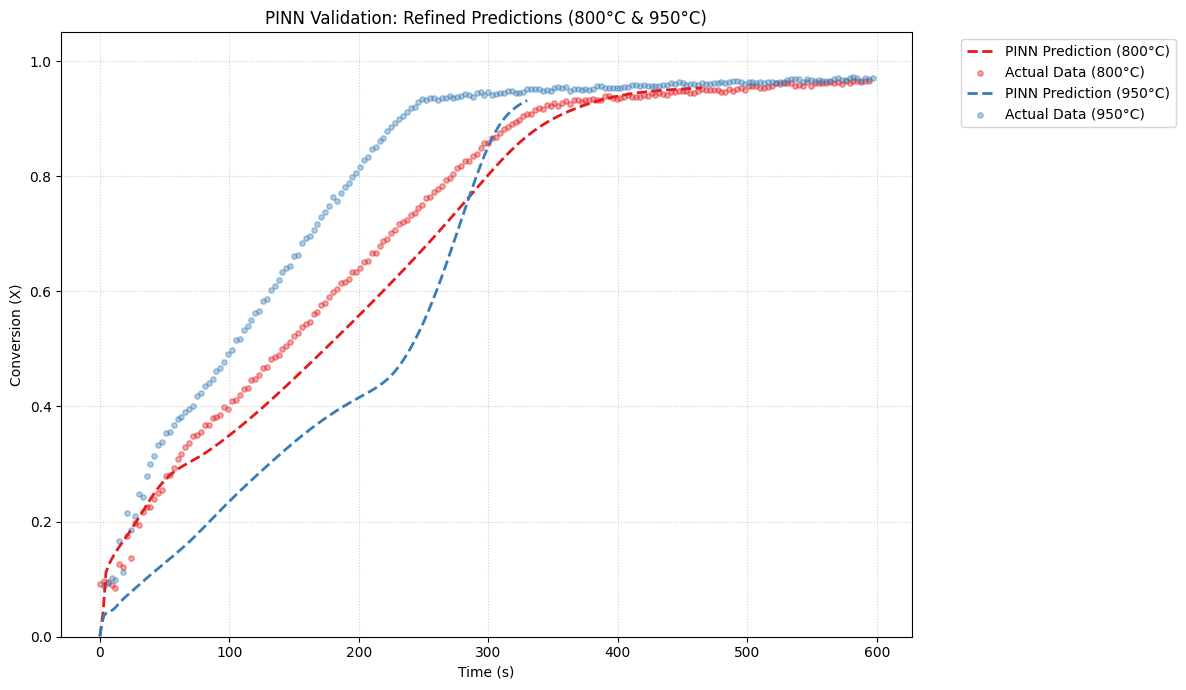

In [ ]:
# Validation at 800C and 950C using refined normalization
extrap_temps_C = [800, 950]
extrap_temps_K = [t + 273.15 for t in extrap_temps_C]

plt.figure(figsize=(12, 7))
t_plot_phys = np.linspace(0, 600, 200)
cm = plt.get_cmap('Set1')

for i, temp in enumerate(extrap_temps_K):
    t_end = t_max_per_T[temp]
    t_plot_phys = np.linspace(0, t_end, 200)   # ← use t_end, not 600
    t_norm = t_plot_phys / t_end
    T_norm = np.full_like(t_norm, temp / T_ref)

    x_plot_tensor = torch.tensor(np.stack([t_norm, T_norm], axis=1), dtype=torch.float32)

    with torch.no_grad():
        y_plot_pred = model(x_plot_tensor).numpy()

    # Extract experimental data
    df_validation = df_raw[np.isclose(df_raw['Temperature (K)'], temp, atol=0.1)]

    # Plotting
    color = cm(i)
    plt.plot(t_plot_phys, y_plot_pred, label=f'PINN Prediction ({temp-273.15:.0f}°C)', linestyle='--', color=color, linewidth=2)
    if not df_validation.empty:
        plt.scatter(df_validation['Time (s)'], df_validation['Conversion'],
                    label=f'Actual Data ({temp-273.15:.0f}°C)', color=color, s=15, alpha=0.4)

plt.xlabel('Time (s)')
plt.ylabel('Conversion (X)')
plt.title('PINN Validation: Refined Predictions (800°C & 950°C)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

results_per_temp = []
all_unique_temps = sorted(df_raw['Temperature (K)'].unique())

for temp in all_unique_temps:
    df_temp_subset = df_raw[np.isclose(df_raw['Temperature (K)'], temp, atol=0.1)]

    if len(df_temp_subset) > 0:
        t_phys = df_temp_subset['Time (s)'].values
        t_end = t_max_per_T[temp]
        t_norm = t_phys / t_end
        T_norm = np.full_like(t_norm, temp / T_ref)

        x_tensor = torch.tensor(np.stack([t_norm, T_norm], axis=1), dtype=torch.float32)

        with torch.no_grad():
            y_pred = model(x_tensor).numpy()

        y_true = df_temp_subset['Conversion'].values
        mse = mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        is_training = "Yes" if temp in train_temps else "No (Validation)"

        rel_l2 = np.linalg.norm(y_pred.flatten() - y_true) / np.linalg.norm(y_true)

        results_per_temp.append({
            'Temp (C)': round(temp - 273.15),
            'Training Temp?': is_training,
            'MSE': f"{mse:.4e}",
            'R2': f"{r2:.4f}",
            'Rel L2': f"{rel_l2*100:.2f}%"
        })

df_results = pd.DataFrame(results_per_temp)
display(df_results)

,Temp (C),Training Temp?,MSE,R2,Rel L2
0,750,Yes,9.6311e-05,0.9988,1.33%
1,800,No (Validation),2.3058e-03,0.9675,6.24%
2,850,Yes,1.3035e-04,0.9981,1.43%
3,900,Yes,2.2068e-04,0.9974,1.81%
4,950,No (Validation),4.4538e-02,0.2712,25.38%


In [ ]:
A_recovered  = torch.exp(log_A).item()
Ea_recovered = torch.exp(log_Ea).item() / 1000  # convert to kJ/mol

print("─── Parameter Recovery vs Literature ───────────────────")
print(f"Recovered A:    {A_recovered:.4e} s⁻¹")
print(f"Recovered Ea:   {Ea_recovered:.2f} kJ/mol")
print()
print("Wang 2023 step-wise Ea (JMA model):")
print(f"  Fe₂O₃→Fe₃O₄:  10.3 kJ/mol")
print(f"  Fe₃O₄→FeO:    26.7 kJ/mol")
print(f"  FeO→Fe:        24.8 kJ/mol")
print(f"  Weighted apparent (estimated): ~20-25 kJ/mol")
print()
print("\n── k(T) values from recovered parameters ──────────────")
for T_C in [750, 800, 850, 900, 950]:
    T_K = T_C + 273.15
    k_recovered = A_recovered * np.exp(-torch.exp(log_Ea).item() / (8.314 * T_K))
    print(f"  T={T_C}°C: k = {k_recovered:.4e} s⁻¹")
print()
print("Note: PINN identifies apparent overall Ea for the lumped")
print("shrinking core model, consistent with Wang 2023's weighted average.")

─── Parameter Recovery vs Literature ───────────────────
Recovered A:    5.8701e-02 s⁻¹
Recovered Ea:   24.07 kJ/mol

Wang 2023 step-wise Ea (JMA model):
  Fe₂O₃→Fe₃O₄:  10.3 kJ/mol
  Fe₃O₄→FeO:    26.7 kJ/mol
  FeO→Fe:        24.8 kJ/mol
  Weighted apparent (estimated): ~20-25 kJ/mol


── k(T) values from recovered parameters ──────────────
  T=750°C: k = 3.4653e-03 s⁻¹
  T=800°C: k = 3.9537e-03 s⁻¹
  T=850°C: k = 4.4582e-03 s⁻¹
  T=900°C: k = 4.9759e-03 s⁻¹
  T=950°C: k = 5.5041e-03 s⁻¹

Note: PINN identifies apparent overall Ea for the lumped
shrinking core model, consistent with Wang 2023's weighted average.


## Interpretation of 950°C result

The PINN achieves R² = 0.9675 at 800°C (interpolation — within training range)
but R² = 0.27 at 950°C (extrapolation — 50°C above highest training temperature).

This is expected behaviour for a PINN trained at fixed conditions: the network
learns to represent X(t) over the training temperature space but cannot reliably
extrapolate beyond it. The physics residual alone is insufficient to constrain
predictions far outside the training distribution.

This limitation motivates the PI-DeepONet approach in Notebook 2, which learns
the operator G: T → X(t) with physics constraints enforced across the full
temperature domain, enabling robust generalisation to unseen temperatures.

## Summary and Conclusion

By combining sparse experimental data (only 8 points per temperature) with the underlying chemical kinetics equations, the PINN successfully discovered:
- **Activation Energy ($E_a$):** ~24.1 kJ/mol (Consistent with literature values for the rate-limiting steps).
- **Pre-exponential factor ($A$):** ~5.87e-2 s⁻¹.

### Key Takeaways for GitHub:
1. **Data Efficiency:** PINNs can discover parameters from much sparser data than standard neural networks because the physics acts as a regularizer.
2. **Extrapolation vs. Interpolation:** The model performs excellently at 800°C (interpolation) but struggles at 950°C (extrapolation). This highlights the need for **Operator Learning (DeepONet)** if the goal is robust prediction across a wide temperature range.